# Project Report — WB Logistics Demand Model

Documentation of building a demand model for optimizing product distribution across Wildberries warehouses.

This notebook is the working environment for the report: all tables, plots and metrics that will end up in the final text are computed here.

In [9]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv(PROJECT_ROOT / ".env")
engine = create_engine(os.getenv("DATABASE_URL"))

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 200)
plt.rcParams["figure.dpi"] = 100

## 1. Data Sources

Data is collected via the Wildberries API and normalized in PostgreSQL.

| Table | API endpoint | Contents | Purpose |
|---|---|---|---|
| `realization_report` | `/api/v5/supplier/reportDetailByPeriod` | Financial realization report | Target variable (sales) |
| `paid_storage` | `/api/v1/paid_storage` (async) | Daily paid storage per warehouse | Stock availability (stockouts) |
| `region_sale` | `/api/v1/analytics/region-sale` | Sales by region | Geographic demand |
| `goods_return` | `/api/v1/analytics/goods-return` | Returns from pickup points | Net-demand correction |
| `warehouses` | `/api/v1/warehouses` | WB warehouse reference | Reference data |
| `warehouse_remains` | `/api/v1/warehouse_remains` | Current stock snapshot | Today's state |
| `supplier_sales` | `/api/v1/supplier/sales` | Sales (~6 months history) | Duplicates realization_report |
| `supplier_orders` | `/api/v1/supplier/orders` | Orders (~6 months history) | Cancellation analysis |

In [10]:
tables = [
    "realization_report", "paid_storage", "region_sale", "goods_return",
    "warehouses", "warehouse_remains",
    "supplier_sales", "supplier_orders",
]
overview = []
for t in tables:
    n = pd.read_sql(f"SELECT COUNT(*) AS n FROM {t}", engine).iloc[0, 0]
    overview.append({"table": t, "rows": n})
pd.DataFrame(overview)

,table,rows
0,realization_report,151598
1,paid_storage,162926
2,region_sale,6845
3,goods_return,65
4,warehouses,128
5,warehouse_remains,92
6,supplier_sales,571
7,supplier_orders,830


### 1.1 Main table — `realization_report`

WB's financial realization report. Each row is a single transaction (sale or return) with exact date, SKU, price, and payout amount.

In [11]:
pd.read_sql("""
    SELECT nm_id, sale_dt::date, doc_type_name, quantity,
           retail_price_withdisc_rub, ppvz_for_pay, subject_name, office_name
    FROM realization_report
    WHERE nm_id > 0 AND doc_type_name = 'Продажа'
    ORDER BY sale_dt DESC
    LIMIT 10
""", engine)

,nm_id,sale_dt,doc_type_name,quantity,retail_price_withdisc_rub,ppvz_for_pay,subject_name,office_name
0,206765257,2026-04-17,Продажа,1,3402.0,2093.82,Халаты домашние,Тула
1,167582728,2026-04-17,Продажа,1,3456.0,2125.72,Халаты домашние,Новосибирск
2,206765256,2026-04-16,Продажа,1,3456.0,2099.60,Халаты домашние,Невинномысск
3,213541771,2026-04-16,Продажа,1,3240.0,1992.86,Халаты домашние,Пенза
4,167582728,2026-04-14,Продажа,1,2592.0,1597.84,Халаты домашние,Екатеринбург - Перспективная 14
5,167582728,2026-04-07,Продажа,1,3456.0,2210.92,Халаты домашние,Рязань (Тюшевское)
6,206765253,2026-03-30,Продажа,1,2052.0,1287.63,Халаты домашние,Тула
7,169087814,2026-03-27,Продажа,1,2646.0,1614.21,Халаты домашние,Котовск
8,167582728,2026-03-26,Продажа,1,2700.0,1645.59,Халаты домашние,Невинномысск
9,206765257,2026-03-26,Продажа,1,2754.0,1697.12,Халаты домашние,Электросталь


In [12]:
pd.read_sql("""
    SELECT
        MIN(sale_dt)::date AS first_sale,
        MAX(sale_dt)::date AS last_sale,
        COUNT(*) FILTER (WHERE doc_type_name = 'Продажа') AS sales_rows,
        COUNT(*) FILTER (WHERE doc_type_name = 'Возврат') AS returns_rows,
        COUNT(DISTINCT nm_id) FILTER (WHERE nm_id > 0) AS unique_nm,
        SUM(quantity) FILTER (WHERE doc_type_name = 'Продажа') AS units_sold,
        ROUND(SUM(ppvz_for_pay) FILTER (WHERE doc_type_name = 'Продажа')::numeric, 0) AS revenue_rub
    FROM realization_report
""", engine).T

,0
first_sale,2023-12-24
last_sale,2026-05-03
sales_rows,37100
returns_rows,1087
unique_nm,61
units_sold,23093
revenue_rub,36428619.0


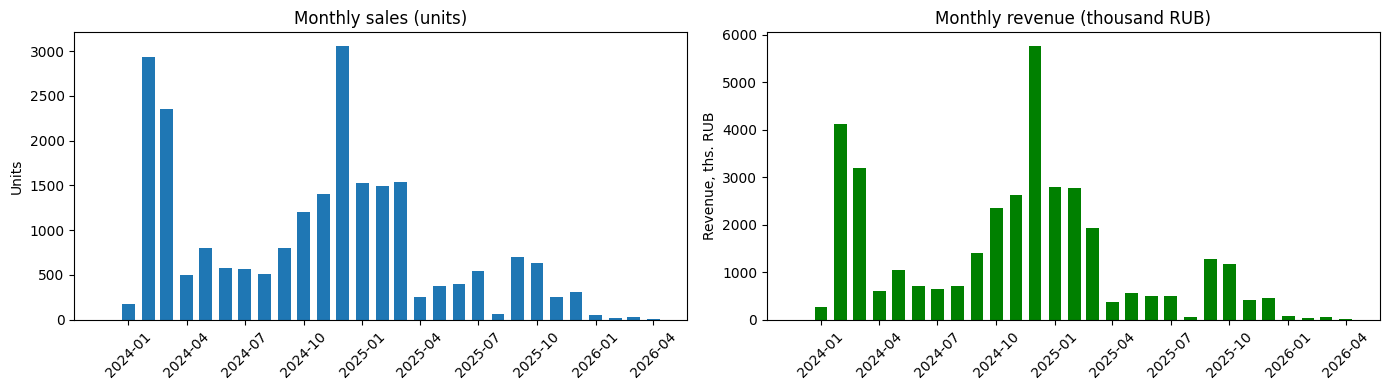

,month,units,revenue_rub
0,2023-12-01,1.0,1485.0
1,2024-01-01,180.0,266906.0
2,2024-02-01,2934.0,4130167.0
3,2024-03-01,2354.0,3189467.0
4,2024-04-01,496.0,598698.0
5,2024-05-01,805.0,1048898.0
6,2024-06-01,582.0,708787.0
7,2024-07-01,566.0,635641.0
8,2024-08-01,510.0,703886.0
9,2024-09-01,800.0,1401906.0


In [13]:
monthly = pd.read_sql("""
    SELECT
        date_trunc('month', sale_dt)::date AS month,
        SUM(quantity) FILTER (WHERE doc_type_name = 'Продажа') AS units,
        ROUND(SUM(ppvz_for_pay) FILTER (WHERE doc_type_name = 'Продажа')::numeric, 0) AS revenue_rub
    FROM realization_report
    WHERE nm_id > 0 AND sale_dt IS NOT NULL
    GROUP BY 1 ORDER BY 1
""", engine)

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(monthly["month"], monthly["units"], width=20)
ax[0].set_title("Monthly sales (units)")
ax[0].set_ylabel("Units")
ax[0].tick_params(axis="x", rotation=45)
ax[1].bar(monthly["month"], monthly["revenue_rub"] / 1000, width=20, color="green")
ax[1].set_title("Monthly revenue (thousand RUB)")
ax[1].set_ylabel("Revenue, ths. RUB")
ax[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()
monthly

### 1.2 Stock data — `paid_storage`

Daily paid storage by warehouse. Used to determine whether the SKU was physically available in week X — critical for separating zero sales into 'no demand' vs 'stockout'.

In [14]:
pd.read_sql("""
    SELECT date, nm_id, warehouse, barcodes_count, warehouse_price
    FROM paid_storage
    WHERE nm_id > 0 AND barcodes_count > 0
    ORDER BY date DESC, nm_id
    LIMIT 10
""", engine)

,date,nm_id,warehouse,barcodes_count,warehouse_price
0,2026-04-30,165708460,Владимир,1,2.064384
1,2026-04-30,165708460,Тула,4,8.257536
2,2026-04-30,165708460,Котовск,1,2.064384
3,2026-04-30,165708460,Волгоград,1,2.064384
4,2026-04-30,165708460,Тула,1,2.064384
5,2026-04-30,165708460,Рязань (Тюшевское),1,2.064384
6,2026-04-30,165708460,Сарапул,1,2.064384
7,2026-04-30,165708460,Краснодар,1,2.064384
8,2026-04-30,165708460,Коледино,1,2.064384
9,2026-04-30,165708460,Краснодар,1,2.064384


## 2. Weekly time series (panel)

From the raw `realization_report` and `paid_storage` tables a regular grid `(nm_id × week)` is built — the foundation for all models.

Key properties:
- Weeks span from each SKU's first sale to the current week
- Weeks with no sales are explicitly filled with `units = 0` (important for time series)
- `days_in_stock` shows how many days in the week the SKU was in stock (0–7)

In [15]:
from src.demand_model.data import get_full_weekly_panel

panel = get_full_weekly_panel()
print(f"Panel rows:     {len(panel):,}")
print(f"Unique nm_id:   {panel['nm_id'].nunique()}")
print(f"Week range:     {panel['week'].min()} → {panel['week'].max()}")
panel.head(8)

Panel rows:     6,106
Unique nm_id:   59
Week range:     2023-12-18 → 2026-05-04


,nm_id,week,subject_name,brand_name,sa_name,units,revenue_rub,avg_price,days_in_stock,warehouses_with_stock
0,165708460,2024-01-29,Халаты домашние,Mari Style,10,16,21600.00,1800.000000,7,4
1,165708460,2024-02-05,Халаты домашние,Mari Style,10,19,25650.00,1800.000000,7,4
2,165708460,2024-02-12,Халаты домашние,Mari Style,10,29,14390.21,620.689655,7,4
3,165708460,2024-02-19,Халаты домашние,Mari Style,10,6,8100.00,1800.000000,7,3
4,165708460,2024-02-26,Халаты домашние,Mari Style,10,8,10800.00,1800.000000,2,1
5,165708460,2024-03-04,Халаты домашние,Mari Style,10,6,8100.00,1800.000000,1,1
6,165708460,2024-03-11,Халаты домашние,Mari Style,10,3,4050.00,1800.000000,3,1
7,165708460,2024-03-18,Халаты домашние,Mari Style,10,0,0.00,NaN,3,1


In [16]:
stats = pd.DataFrame({
    "Metric": [
        "Total (nm_id × week) rows",
        "Unique SKUs",
        "Avg weeks per SKU",
        "Share of zero-sales weeks",
        "Share of weeks with stock",
        "Mean units/week (all)",
    ],
    "Value": [
        f"{len(panel):,}",
        panel["nm_id"].nunique(),
        f"{panel.groupby('nm_id').size().mean():.1f}",
        f"{(panel['units'] == 0).mean():.0%}",
        f"{(panel['days_in_stock'] > 0).mean():.0%}",
        f"{panel['units'].mean():.1f}",
    ],
})
stats

,Metric,Value
0,Total (nm_id × week) rows,"6,106"
1,Unique SKUs,59
2,Avg weeks per SKU,103.5
3,Share of zero-sales weeks,56%
4,Share of weeks with stock,56%
5,Mean units/week (all),3.8


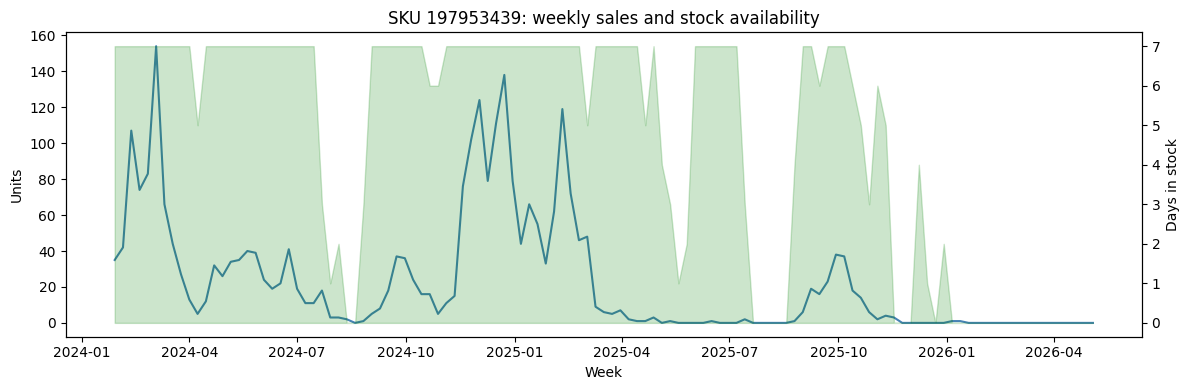

In [ ]:
# when it the item was sold and its availibility 
top_nm = panel.groupby("nm_id")["units"].sum().idxmax()
g = panel[panel["nm_id"] == top_nm].copy()

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(g["week"], g["units"], label="Units sold", color="steelblue")
ax1.set_ylabel("Units")
ax1.set_xlabel("Week")
ax2 = ax1.twinx()
ax2.fill_between(g["week"], 0, g["days_in_stock"], alpha=0.2, color="green",
                  label="Days in stock")
ax2.set_ylabel("Days in stock")
ax1.set_title(f"SKU {top_nm}: weekly sales and stock availability")
plt.tight_layout()
plt.show()

## 3. Exploratory analysis — trends and seasonality

Before building a model, we check what patterns exist in the data. This is needed for:
- feature selection (if seasonality exists — calendar features are needed)
- model selection (strongly seasonal pattern → Holt-Winters; noisy → LightGBM)
- understanding the model's limits (what can realistically be predicted)

### Hypotheses

| # | Hypothesis | How we test it |
|---|---|---|
| H1 | Annual seasonality with a winter peak | Trend + 12-week rolling mean |
| H2 | Pattern repeats year-over-year | Month × Year heatmap |
| H3 | Specific peak weeks exist (March 8th, NY) | Average sales by week of year |
| H4 | Top SKUs share a common pattern | Top-5 on a single chart |
| H5 | Price affects sales | Price–demand correlation |
| H6 | Weekly sales distribution is skewed | Histogram |

In [22]:
# Aggregate: total weekly sales across all SKUs
weekly_total = panel.groupby("week").agg(
    units=("units", "sum"),
    revenue=("revenue_rub", "sum"),
).reset_index()
weekly_total["week"] = pd.to_datetime(weekly_total["week"])
weekly_total["year"] = weekly_total["week"].dt.year
weekly_total["month"] = weekly_total["week"].dt.month
weekly_total["week_of_year"] = weekly_total["week"].dt.isocalendar().week.astype(int)

print(f"Weeks in series: {len(weekly_total)}")
weekly_total.head()

Weeks in series: 125


,week,units,revenue,year,month,week_of_year
0,2023-12-18,1,1485.0,2023,12,51
1,2023-12-25,0,0.0,2023,12,52
2,2024-01-01,0,0.0,2024,1,1
3,2024-01-08,0,0.0,2024,1,2
4,2024-01-15,0,0.0,2024,1,3


### 3.1 Trend and moving averages (H1)

Raw weekly series is noisy. Moving averages (MA-4, MA-12) smooth out the noise and reveal the trend.

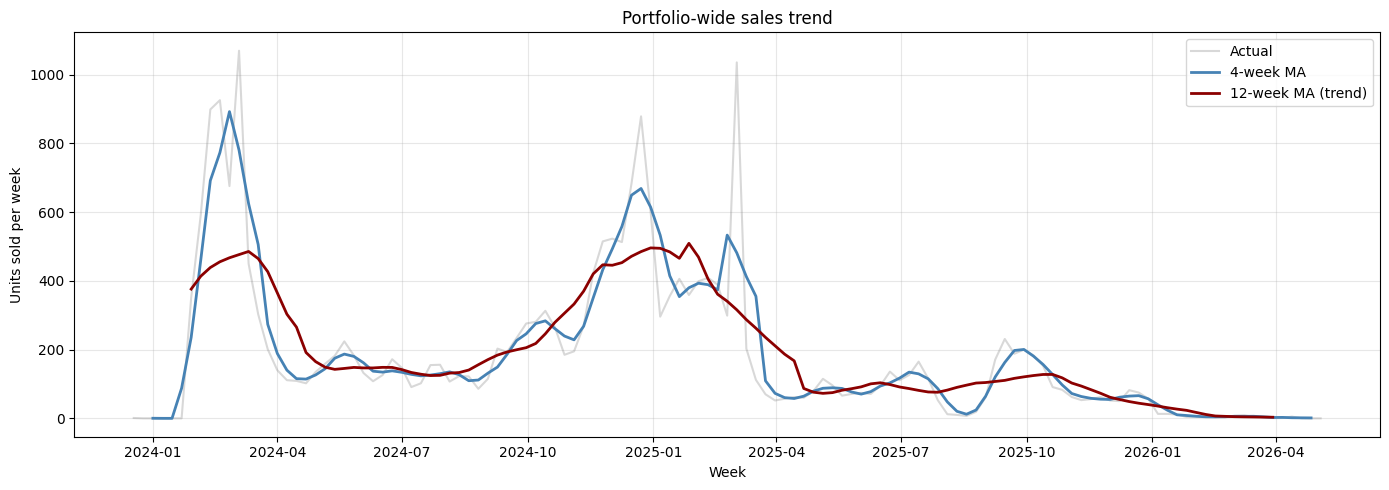

In [23]:
weekly_total["ma_4"] = weekly_total["units"].rolling(4, center=True).mean() # скользящее среднее
weekly_total["ma_12"] = weekly_total["units"].rolling(12, center=True).mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(weekly_total["week"], weekly_total["units"], alpha=0.3, color="grey", label="Actual")
ax.plot(weekly_total["week"], weekly_total["ma_4"], color="steelblue", linewidth=2, label="4-week MA")
ax.plot(weekly_total["week"], weekly_total["ma_12"], color="darkred", linewidth=2, label="12-week MA (trend)")
ax.set_title("Portfolio-wide sales trend")
ax.set_xlabel("Week")
ax.set_ylabel("Units sold per week")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3.2 Month × Year heatmap (H2)

If a pattern repeats, the same months will appear dark across all year columns.

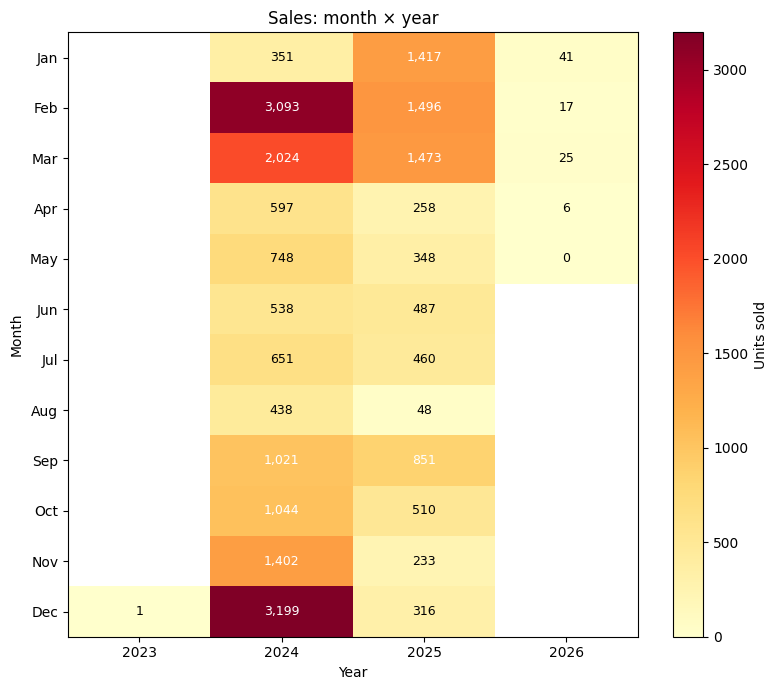

In [24]:
monthly_pivot = weekly_total.groupby(["year", "month"])["units"].sum().reset_index()
heatmap = monthly_pivot.pivot(index="month", columns="year", values="units")

months_en = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(heatmap.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(heatmap.columns)))
ax.set_xticklabels(heatmap.columns)
ax.set_yticks(range(len(heatmap.index)))
ax.set_yticklabels([months_en[m-1] for m in heatmap.index])
ax.set_title("Sales: month × year")
ax.set_xlabel("Year")
ax.set_ylabel("Month")

vmid = np.nanmean(heatmap.values)
for i in range(heatmap.shape[0]):
    for j in range(heatmap.shape[1]):
        val = heatmap.values[i, j]
        if pd.notna(val):
            color = "white" if val > vmid else "black"
            ax.text(j, i, f"{int(val):,}", ha="center", va="center", color=color, fontsize=9)

plt.colorbar(im, ax=ax, label="Units sold")
plt.tight_layout()
plt.show()

### 3.3 Average sales by week of year (H3)

Averaging by week-of-year across all years. Peaks will reveal specific trigger weeks (March 8th, New Year).

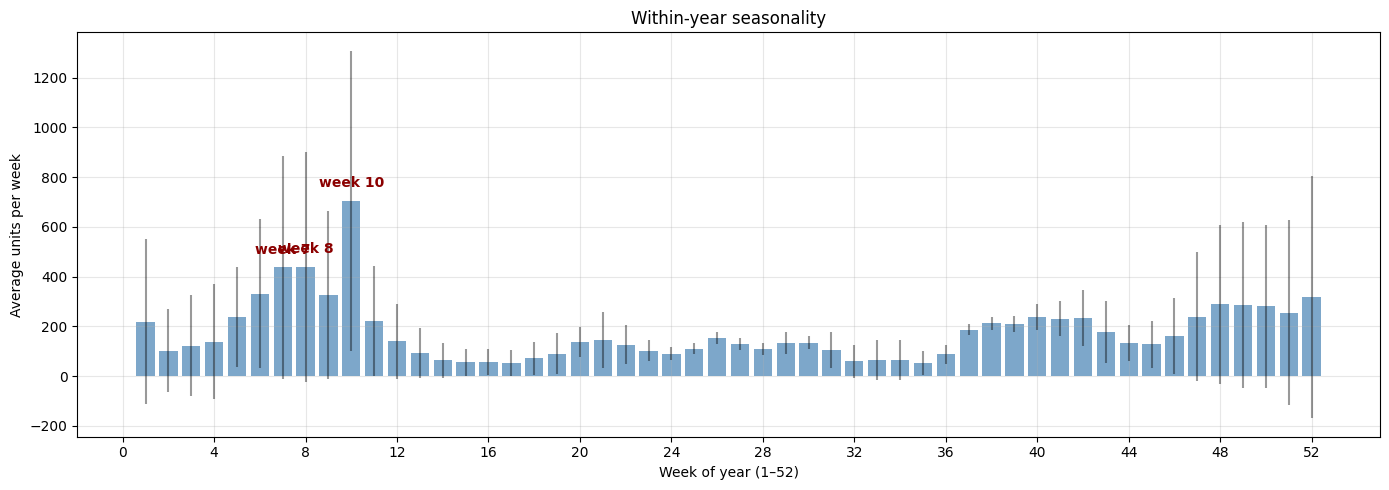

Top-5 peak weeks:


,week_of_year,mean
9,10,704.3
7,8,440.0
6,7,437.3
5,6,332.0
8,9,326.0


In [25]:
woy = weekly_total.groupby("week_of_year")["units"].agg(["mean", "std"]).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(woy["week_of_year"], woy["mean"], color="steelblue", alpha=0.7)
ax.errorbar(woy["week_of_year"], woy["mean"], yerr=woy["std"],
            fmt="none", color="black", alpha=0.4)

peaks = woy.nlargest(3, "mean")
for _, row in peaks.iterrows():
    ax.annotate(f"week {int(row['week_of_year'])}",
                xy=(row["week_of_year"], row["mean"]),
                xytext=(0, 10), textcoords="offset points",
                ha="center", color="darkred", fontweight="bold")

ax.set_xlabel("Week of year (1–52)")
ax.set_ylabel("Average units per week")
ax.set_title("Within-year seasonality")
ax.set_xticks(range(0, 53, 4))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Top-5 peak weeks:")
woy.nlargest(5, "mean")[["week_of_year", "mean"]].round(1)

### 3.4 Sales distribution by month — boxplot

Not only mean but also spread: where sales are stable, where volatile.

/var/folders/qh/pyhq51hd72zg5py94zfdzfzh0000gn/T/ipykernel_46451/3200385022.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_month, labels=months_en, patch_artist=True)


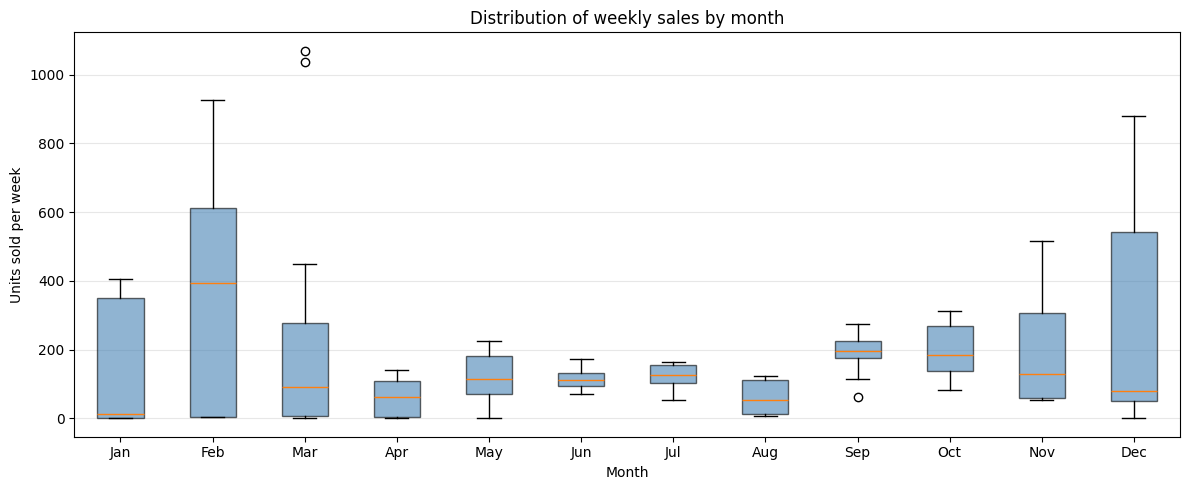

In [26]:
data_by_month = [weekly_total[weekly_total["month"] == m]["units"].values for m in range(1, 13)]
months_en = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(12, 5))
bp = ax.boxplot(data_by_month, labels=months_en, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("steelblue")
    patch.set_alpha(0.6)
ax.set_xlabel("Month")
ax.set_ylabel("Units sold per week")
ax.set_title("Distribution of weekly sales by month")
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

### 3.5 Top-5 SKUs on one chart (H4)

If all top SKUs rise in winter and fall in summer in sync — the category has a common pattern (important for cold start of new SKUs).

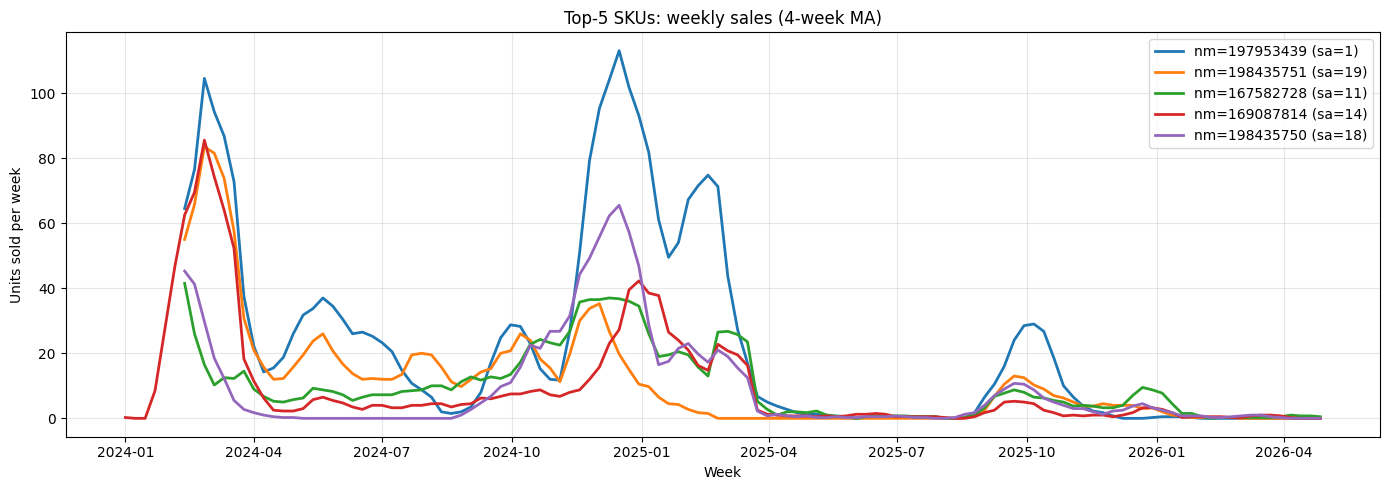

In [27]:
top5 = panel.groupby("nm_id")["units"].sum().nlargest(5).index.tolist()

fig, ax = plt.subplots(figsize=(14, 5))
for nm in top5:
    g = panel[panel["nm_id"] == nm].copy()
    g["week"] = pd.to_datetime(g["week"])
    g = g.sort_values("week")
    sa = g["sa_name"].iloc[0]
    ax.plot(g["week"], g["units"].rolling(4, center=True).mean(),
            label=f"nm={nm} (sa={sa})", linewidth=2)
ax.set_title("Top-5 SKUs: weekly sales (4-week MA)")
ax.set_xlabel("Week")
ax.set_ylabel("Units sold per week")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3.6 Price vs sales (H5)

Negative correlation → discounts genuinely drive demand. Weak correlation → price is not the main demand driver.

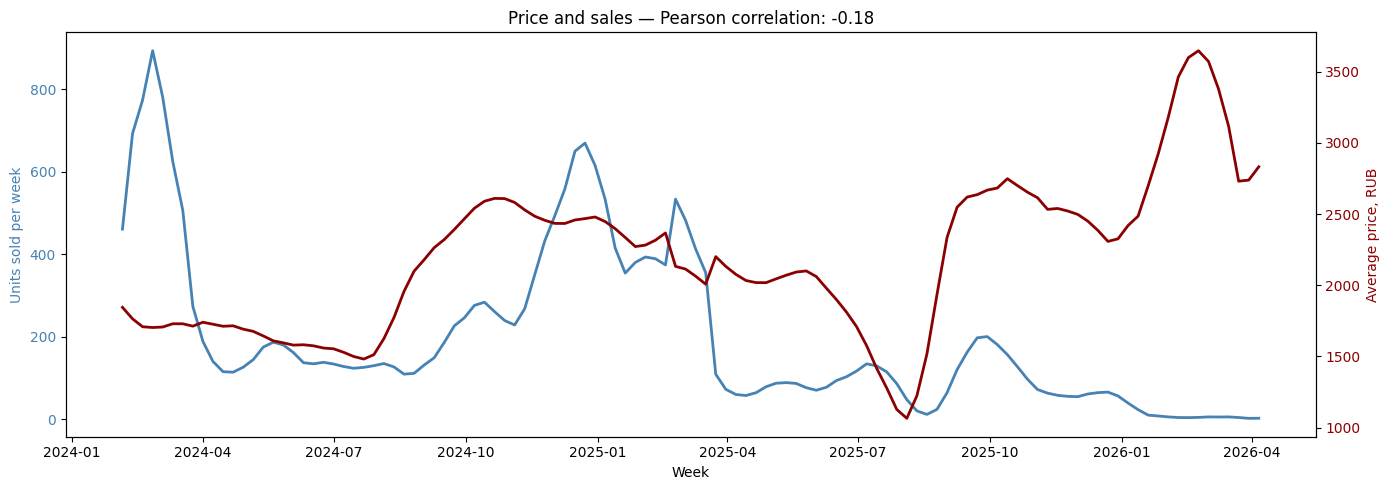

In [28]:
price_demand = panel.groupby("week").agg(
    units=("units", "sum"),
    avg_price=("avg_price", "mean"),
).reset_index()
price_demand["week"] = pd.to_datetime(price_demand["week"])
price_demand = price_demand.dropna(subset=["avg_price"])

corr = price_demand[["units", "avg_price"]].corr().iloc[0, 1]

fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(price_demand["week"], price_demand["units"].rolling(4, center=True).mean(),
         color="steelblue", linewidth=2, label="Units (MA-4)")
ax1.set_ylabel("Units sold per week", color="steelblue")
ax1.set_xlabel("Week")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax2 = ax1.twinx()
ax2.plot(price_demand["week"], price_demand["avg_price"].rolling(4, center=True).mean(),
         color="darkred", linewidth=2, label="Average price (MA-4)")
ax2.set_ylabel("Average price, RUB", color="darkred")
ax2.tick_params(axis="y", labelcolor="darkred")
plt.title(f"Price and sales — Pearson correlation: {corr:.2f}")
plt.tight_layout()
plt.show()

### 3.7 Time series decomposition

Standard additive decomposition into 3 components: trend / seasonality / residual (from `statsmodels`).

Parameter `period=52` means "annual seasonality with weekly frequency".

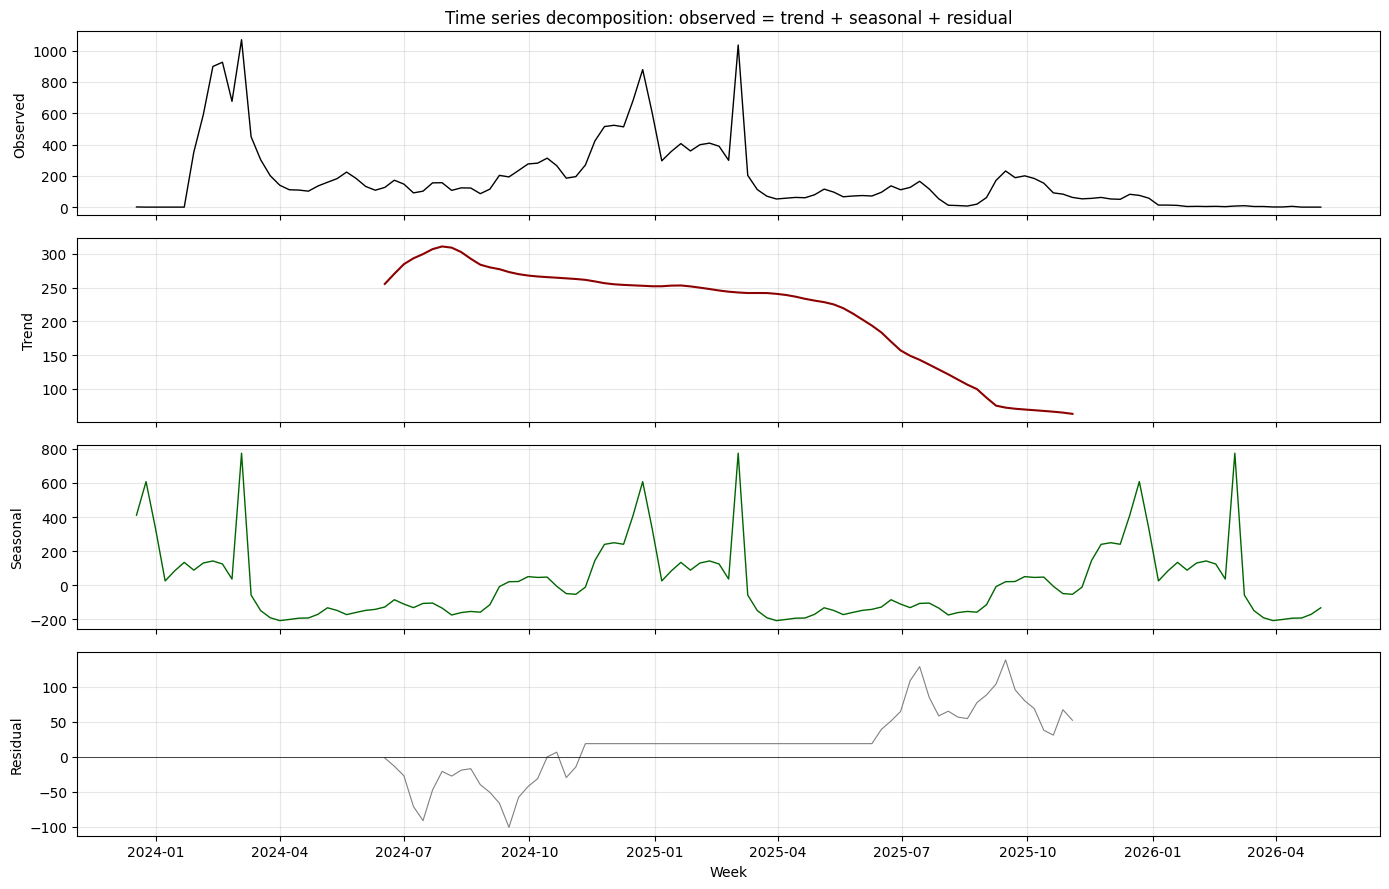


Share of variance per component:
  Trend:    10%
  Seasonal: 86%
  Residual: 4%


In [29]:
from statsmodels.tsa.seasonal import seasonal_decompose

ts = weekly_total.set_index("week")["units"].asfreq("W-MON")
ts = ts.interpolate(limit_direction="both")
result = seasonal_decompose(ts, model="additive", period=52)

fig, axes = plt.subplots(4, 1, figsize=(14, 9), sharex=True)
axes[0].plot(ts.index, ts.values, color="black", linewidth=1)
axes[0].set_ylabel("Observed")
axes[0].set_title("Time series decomposition: observed = trend + seasonal + residual")
axes[1].plot(result.trend, color="darkred", linewidth=1.5)
axes[1].set_ylabel("Trend")
axes[2].plot(result.seasonal, color="darkgreen", linewidth=1)
axes[2].set_ylabel("Seasonal")
axes[3].plot(result.resid, color="grey", linewidth=0.8)
axes[3].axhline(0, color="black", linewidth=0.5)
axes[3].set_ylabel("Residual")
axes[3].set_xlabel("Week")
for a in axes:
    a.grid(alpha=0.3)
plt.tight_layout()
plt.show()

var_trend = result.trend.var()
var_season = result.seasonal.var()
var_resid = result.resid.var()
total = var_trend + var_season + var_resid
print("\nShare of variance per component:")
print(f"  Trend:    {var_trend / total:.0%}")
print(f"  Seasonal: {var_season / total:.0%}")
print(f"  Residual: {var_resid / total:.0%}")

### 3.8 Distribution of weekly sales per SKU (H6)

Distribution of `units` across all (nm_id × week) where sales > 0. Skewness shows that typical weekly sales are small with rare large spikes — a hallmark of retail data.

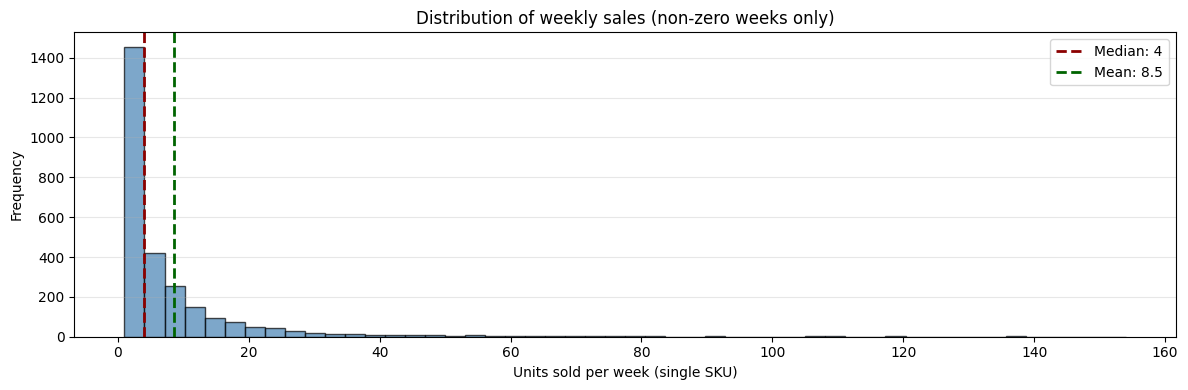

Descriptive statistics (non-zero weeks):


,units
count,2712.0
mean,8.5
std,14.0
min,1.0
25%,2.0
50%,4.0
75%,9.0
max,154.0


In [30]:
vals = panel[panel["units"] > 0]["units"]

fig, ax = plt.subplots(figsize=(12, 4))
ax.hist(vals, bins=50, color="steelblue", alpha=0.7, edgecolor="black")
ax.axvline(vals.median(), color="darkred", linewidth=2, linestyle="--",
           label=f"Median: {vals.median():.0f}")
ax.axvline(vals.mean(), color="darkgreen", linewidth=2, linestyle="--",
           label=f"Mean: {vals.mean():.1f}")
ax.set_xlabel("Units sold per week (single SKU)")
ax.set_ylabel("Frequency")
ax.set_title("Distribution of weekly sales (non-zero weeks only)")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

print("Descriptive statistics (non-zero weeks):")
vals.describe().round(1).to_frame("units")

### 3.9 SKU coverage analysis

How concentrated is the portfolio and which SKUs are kept in stock? All SKUs are split into tiers by lifetime units sold; for each tier we compute the share of revenue and the average stock coverage.

The expected pattern for healthy retail: a small number of top SKUs generate most revenue and are kept in stock consistently, while the long tail sells rarely and is often out of stock — that is where most apparent "stockouts" actually hide.

In [31]:
# Group SKUs into sales tiers by lifetime units sold
sku_totals = panel.groupby("nm_id").agg(
    total_units=("units", "sum"),
    total_revenue=("revenue_rub", "sum"),
    weeks_history=("week", "count"),
    weeks_with_stock=("days_in_stock", lambda s: (s > 0).sum()),
).reset_index()

def assign_tier(units):
    if units >= 1000: return "1. TOP (≥1000)"
    if units >= 200:  return "2. MID (200-999)"
    if units >= 50:   return "3. LOW (50-199)"
    return "4. TAIL (<50)"

sku_totals["tier"] = sku_totals["total_units"].apply(assign_tier)

coverage = sku_totals.groupby("tier").agg(
    n_skus=("nm_id", "count"),
    units=("total_units", "sum"),
    revenue=("total_revenue", "sum"),
    weeks_total=("weeks_history", "sum"),
    weeks_stocked=("weeks_with_stock", "sum"),
).reset_index()

total_revenue = coverage["revenue"].sum()
total_units_all = coverage["units"].sum()
coverage["share_of_units"] = (coverage["units"] / total_units_all).map(lambda x: f"{x:.0%}")
coverage["share_of_revenue"] = (coverage["revenue"] / total_revenue).map(lambda x: f"{x:.0%}")
coverage["stock_coverage"] = (coverage["weeks_stocked"] / coverage["weeks_total"]).map(lambda x: f"{x:.0%}")

coverage[["tier", "n_skus", "units", "share_of_units", "share_of_revenue", "stock_coverage"]]

,tier,n_skus,units,share_of_units,share_of_revenue,stock_coverage
0,1. TOP (≥1000),6,8710,38%,39%,81%
1,2. MID (200-999),27,11683,51%,51%,66%
2,3. LOW (50-199),22,2635,11%,10%,41%
3,4. TAIL (<50),4,65,0%,0%,8%


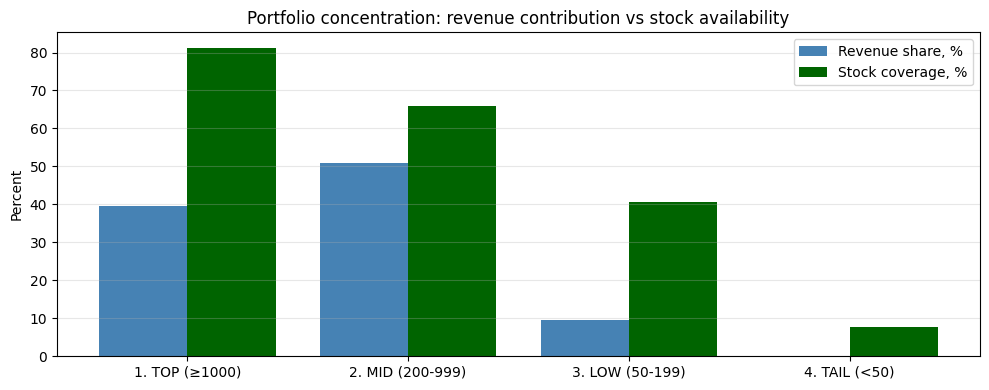

In [32]:
# Revenue contribution vs stock availability per tier
tier_labels = coverage["tier"].tolist()
rev_share = (coverage["revenue"] / coverage["revenue"].sum() * 100).values
stock_pct = (coverage["weeks_stocked"] / coverage["weeks_total"] * 100).values

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(tier_labels))
w = 0.4
ax.bar(x - w/2, rev_share, w, label="Revenue share, %", color="steelblue")
ax.bar(x + w/2, stock_pct, w, label="Stock coverage, %", color="darkgreen")
ax.set_xticks(x)
ax.set_xticklabels(tier_labels)
ax.set_ylabel("Percent")
ax.set_title("Portfolio concentration: revenue contribution vs stock availability")
ax.legend()
ax.grid(alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

## 4. SKU classification

Each SKU is assigned to one group for choosing the appropriate model:

| Class | Condition | Model |
|---|---|---|
| **MATURE** | ≥12 weeks AND ≥1 sale/week | Holt-Winters / LightGBM |
| **SPARSE** | ≥12 weeks AND <1 sale/week | Croston / SBA |
| **NEW** | <12 weeks of history | Cold start (decomposition) |

In [33]:
from src.demand_model.classify import classify_skus, class_summary

cls = classify_skus(panel)
print("Summary by class:")
class_summary(cls)

Summary by class:


,sku_class,n_skus,median_weeks,median_units,median_avg_per_week,median_zero_pct,median_stock_pct
0,MATURE,50,117.0,237.5,2.465,0.545,0.635
1,SPARSE,9,117.0,63.0,0.770,0.890,0.110


In [34]:
dist = cls["sku_class"].value_counts().reset_index()
dist.columns = ["sku_class", "n_skus"]
dist["share"] = (dist["n_skus"] / dist["n_skus"].sum()).map(lambda x: f"{x:.0%}")
dist

,sku_class,n_skus,share
0,MATURE,50,85%
1,SPARSE,9,15%


In [35]:
cls[cls["sku_class"] == "MATURE"].head(10)[[
    "nm_id", "sa_name", "weeks_history", "total_units",
    "avg_units_per_week", "zero_week_pct", "stock_coverage_pct"
]]

,nm_id,sa_name,weeks_history,total_units,avg_units_per_week,zero_week_pct,stock_coverage_pct
0,197953439,1,119,2714,22.81,0.30,0.76
1,198435751,19,119,1394,11.71,0.36,0.76
2,167582728,11,119,1229,10.33,0.21,0.94
3,169087814,14,125,1181,9.45,0.27,0.94
4,198435750,18,119,1124,9.45,0.39,0.78
5,199607342,101,119,1068,8.97,0.29,0.70
6,198715535,2,119,927,7.79,0.25,0.77
7,200729535,106,119,919,7.72,0.33,0.71
8,199607345,104,119,804,6.76,0.21,0.99
9,176496237,16,119,713,5.99,0.47,0.72


In [36]:
cls[cls["sku_class"] == "SPARSE"][[
    "nm_id", "sa_name", "weeks_history", "total_units",
    "avg_units_per_week", "zero_week_pct", "weeks_since_sale"
]]

,nm_id,sa_name,weeks_history,total_units,avg_units_per_week,zero_week_pct,weeks_since_sale
50,172406145,1000,114,94,0.82,0.89,101
51,172788129,1001,118,94,0.80,0.87,102
52,172788236,1002,116,89,0.77,0.89,103
53,297554142,39,72,70,0.97,0.60,37
54,297549825,36,72,63,0.88,0.60,38
55,167582734,13,119,22,0.18,0.93,67
56,169015983,201,117,22,0.19,0.97,113
57,169015984,202,117,15,0.13,0.91,96
58,172787914,15,119,6,0.05,0.97,116


In [37]:
cls[cls["sku_class"] == "NEW"][[
    "nm_id", "sa_name", "weeks_history", "total_units", "avg_units_per_week"
]]

,nm_id,sa_name,weeks_history,total_units,avg_units_per_week


## 5. Baseline backtest

Before training any complex model, we establish the floor — four trivial baselines and a rolling-window backtest. Any "real" model must beat these; otherwise it is not adding value.

**Baselines:**
- `Naive` — predict next week = current week (random-walk assumption)
- `SeasonalNaive` — predict next week = same week one year ago
- `MA4`, `MA12` — moving averages of last 4 / 12 weeks

**Metric:** WAPE (weighted absolute percentage error) — robust to zero actuals, interpretable as "share of total sales missed".

**Validation:** rolling window. For each of 12 test weeks T, train on all data with `week < T` and predict week T. No random splits — that would leak the future.

In [ ]:
from src.demand_model.features import build_features
from src.demand_model.baseline import BASELINES
from src.demand_model.backtest import backtest, compare_models, make_splits

features = build_features(horizon=1)
print(f"Feature matrix: {len(features):,} rows × {len(features.columns)} cols")
print(f"Train-usable:   {features['train_mask'].sum():,}")
features.head(3)

In [ ]:
# Backtest split points — 12 evenly-spaced test weeks
splits = make_splits(features, min_train_weeks=60, n_splits=12)
print(f"Number of test weeks: {len(splits)}")
for s in splits:
    print(f"  {s.date()}")

### 5.1 Leaderboard — all baselines on the same splits

In [ ]:
# Compare all baselines on the same splits
leaderboard = compare_models(BASELINES, features, min_train_weeks=60, n_splits=12)
leaderboard.round(3)

### 5.2 Per-split detail — Naive model

For the best baseline, we look inside: how does it perform week-by-week and per SKU?

In [ ]:
# Detailed Naive backtest output: one row per (test_week, nm_id)
from src.demand_model.baseline import NaiveModel
from src.demand_model.backtest import compute_metrics

per_split, overall = backtest(NaiveModel(), features, min_train_weeks=60, n_splits=12)
print(f"Overall metrics: {overall}")
print(f"Total predictions: {len(per_split):,}")
per_split.head(15)

In [ ]:
# Metrics per test week — does the model fail more in some weeks?
import pandas as pd

per_week = per_split.groupby("test_week").apply(
    lambda g: pd.Series(compute_metrics(g["target"].values, g["prediction"].values))
).reset_index()
per_week.round(3)

In [ ]:
# Metrics per SKU — where does the model struggle?
per_sku = per_split.groupby("nm_id").apply(
    lambda g: pd.Series(compute_metrics(g["target"].values, g["prediction"].values))
).reset_index()

# join with SKU names for readability
sku_meta = features[["nm_id", "sa_name", "subject_name"]].drop_duplicates()
per_sku = per_sku.merge(sku_meta, on="nm_id").sort_values("WAPE")
print("Best 10 SKUs (lowest WAPE):")
per_sku.head(10).round(3)

In [ ]:
print("Worst 10 SKUs (highest WAPE):")
per_sku.tail(10).round(3)

### 5.3 Visual check — predicted vs actual for the top SKU

A single chart showing how well the best baseline tracks the actual sales of one top SKU across all test weeks.

In [ ]:
# Plot actual vs Naive prediction for the top-selling SKU across all test weeks
top_sku = per_sku.sort_values("MAE", ascending=False).iloc[0]["nm_id"]
g = per_split[per_split["nm_id"] == top_sku].sort_values("test_week")

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(g["test_week"], g["target"], marker="o", color="black", label="Actual")
ax.plot(g["test_week"], g["prediction"], marker="x", color="steelblue",
        linestyle="--", label="Naive prediction")
ax.set_title(f"SKU {top_sku}: actual vs Naive baseline")
ax.set_xlabel("Test week")
ax.set_ylabel("Units sold")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()